# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [5]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [6]:
df.shape

(17379, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [27]:
from sklearn.model_selection import train_test_split

# Remove instant, dteday, mnth because they don't give valuable information
# Remove casual and registered because they sum the cnt which will be the target variable
# Remove atemp because of the correlation with temp

df_model = df.drop(['instant','dteday','mnth','atemp','casual','registered'], axis=1)

target = 'cnt'

X = df_model.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [28]:
# Your code here

# Remove instant, dteday, mnth because they don't give valuable information
# Remove casual and registered because they sum the cnt which will be the target variable
# Remove atemp because of the correlation with temp

df_model = df.drop(['instant','dteday','mnth','atemp','casual','registered'], axis=1)

# One hot encoding for season, wheatersit
# Transform the other features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['season', 'weathersit', 'weekday']

num_cols = ['yr','hr', 'temp', 'hum', 'windspeed']

other_cols = ['workingday','holiday']

ct = ColumnTransformer([
    ('categorical', OneHotEncoder(), cat_cols),
    ('quantitative', StandardScaler(), num_cols),
],remainder='passthrough')

X_train_scaled = ct.fit_transform(X_train)
X_test_scaled = ct.transform(X_test)


## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [35]:
# Your code here

from sklearn.model_selection import GridSearchCV

#-*-*-*-*-*-*XGB-*-*-*-*-*-*

from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

# Define a parameter grid for hyperparameter tuning
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Create the GridSearchCV object
grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2
)

# Fit the grid search to the scaled training data
grid_xgb.fit(X_train_scaled, y_train)

# Get the best parameters
print("Best XGBoost parameters:", grid_xgb.best_params_)


#-*-*-*-*-*-*LINEAR REGRESSION-*-*-*-*-*-*

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# Define a parameter grid for hyperparameter tuning
param_grid_lr = {
    'fit_intercept': [True, False]
}

# Create the GridSearchCV object
grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2
)

# Fit the grid search to the scaled training data
grid_lr.fit(X_train_scaled, y_train)

# Get the best parameters
print("Best Linear Regression parameters:", grid_lr.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.6s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.2

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [36]:
# Your code here

# Create an SVR model with the best parameters from the grid search
#best_svr = SVR(kernel=best_params['kernel'], C=best_params['C'], epsilon=best_params['epsilon'])

# Perform cross-validation on the entire dataset
#cv_scores = cross_val_score(best_svr, x , y, cv=5, verbose=2).mean()
#print(cv_scores)

#best_svr.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
best_lr = grid_lr.best_estimator_

xgb_predictions = best_xgb.predict(X_test_scaled)
lr_predictions = best_lr.predict(X_test_scaled)

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [37]:
# Your code here

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_xgb = best_xgb.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
print("XGB")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print()

y_pred_lr = best_lr.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
print("LR")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

XGB
Mean Absolute Error: 23.589349391902353
Mean Squared Error: 1501.6676324507916
R-squared: 0.9525770369285586

LR
Mean Absolute Error: 103.77362778773814
Mean Squared Error: 19039.556780559375
R-squared: 0.39872700284051166


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

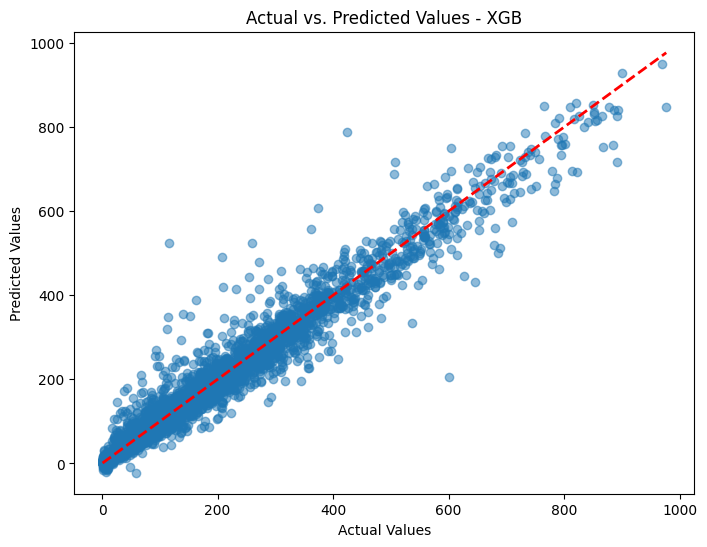

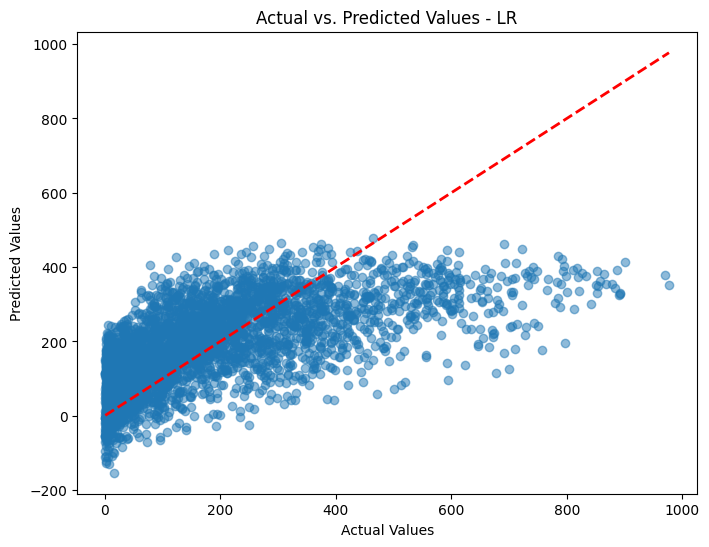

In [38]:
# Your Code here

import matplotlib.pyplot as plt
import seaborn as sns

# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset


#-*-*-*-*-*-*XGB-*-*-*-*-*-*

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values - XGB")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()


#-*-*-*-*-*-*LINEAR REGRESSION-*-*-*-*-*-*

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values - LR")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

Mean Absolute Error: 3.767406455570414
Mean Squared Error: 22.6428879730169
R-squared: 0.48103356337208236


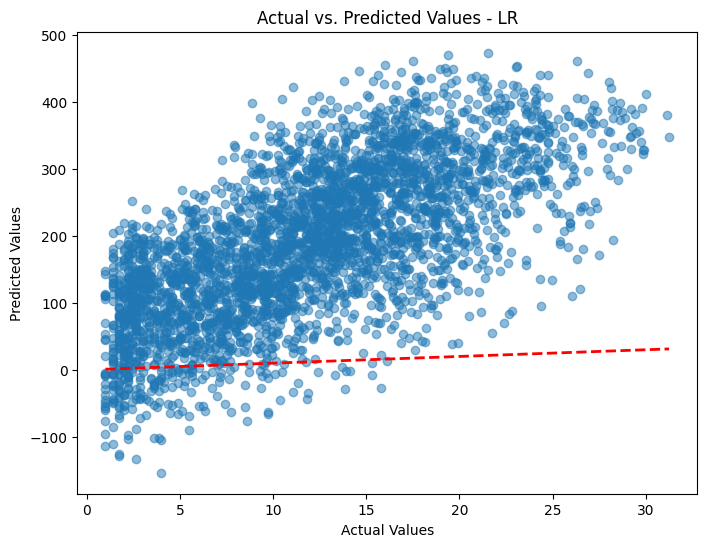

In [27]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

y_train2 = y_train
y_test2 = y_test
##########################################
y_train2 = np.sqrt(y_train)
y_test2 = np.sqrt(y_test)
##########################################


# Create a Linear Regression model
model = LinearRegression()

cross_val_score(model, X_train_scaled, y_train2, cv=5).mean()


# Fit the model to the training data
model.fit(X_train_scaled, y_train2)

y_pred = model.predict(X_test_scaled)


mae = mean_absolute_error(y_test2, y_pred)
mse = mean_squared_error(y_test2, y_pred)
r2 = r2_score(y_test2, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")


# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test2, y_pred_lr, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values - LR")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test2), max(y_test2)], [min(y_test2), max(y_test2)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
Mean Squared Error: 19379.828367651717
Mean Absol

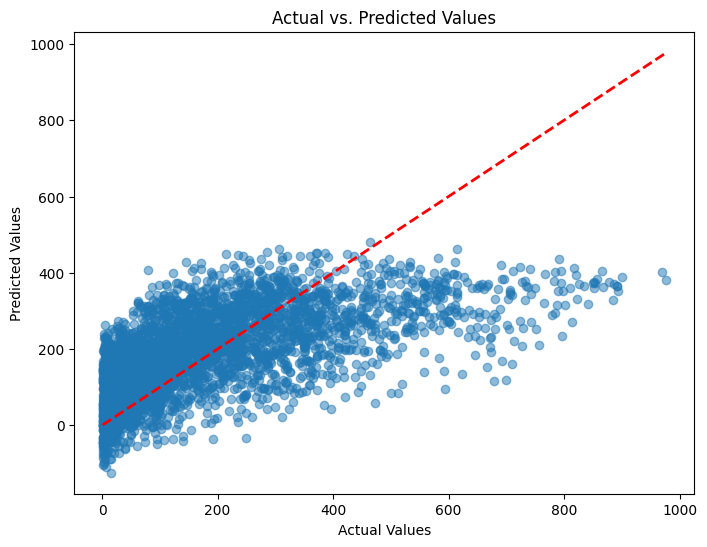

/usr/local/lib/python3.13/dist-packages/xgboost/sklearn.py:1183: UserWarning: [15:31:29] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1553: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


XGBoost Mean Squared Error: 1619.3082275390625
XGBoost Mean Absolute Error: 25.00953483581543
XGBoost Root Mean Squared Error: 40.24062728881836
XGBoost R2 Score: 0.9488619565963745


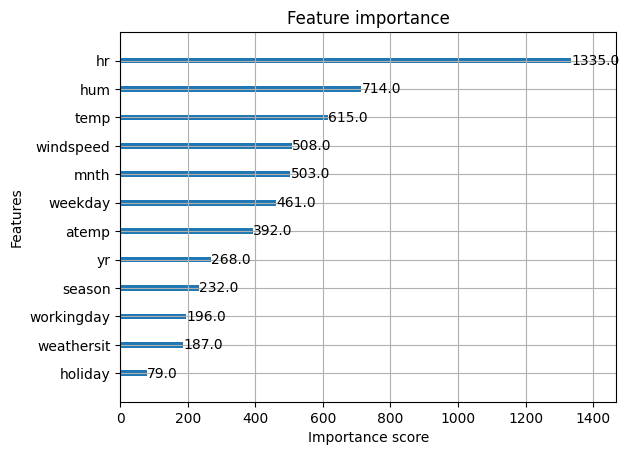

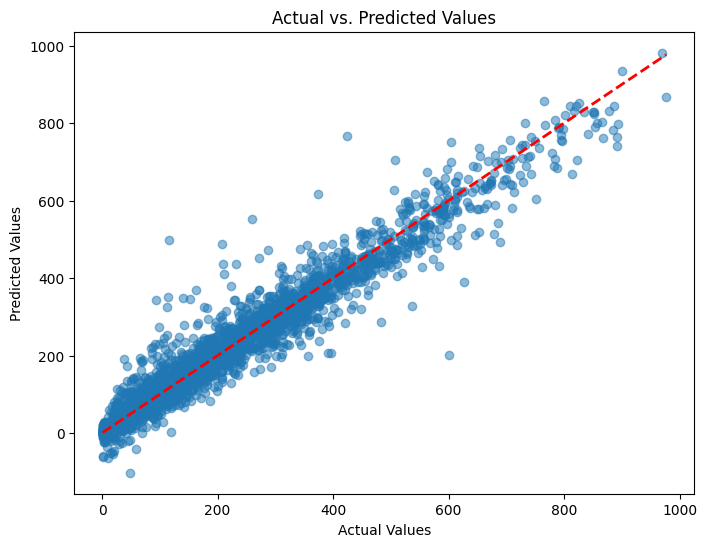

SVM Mean Squared Error: 12393.152957681026
SVM Mean Absolute Error: 66.29546631298759
SVM Root Mean Squared Error: 111.32453888375656
SVM R2 Score: 0.6086217600018144


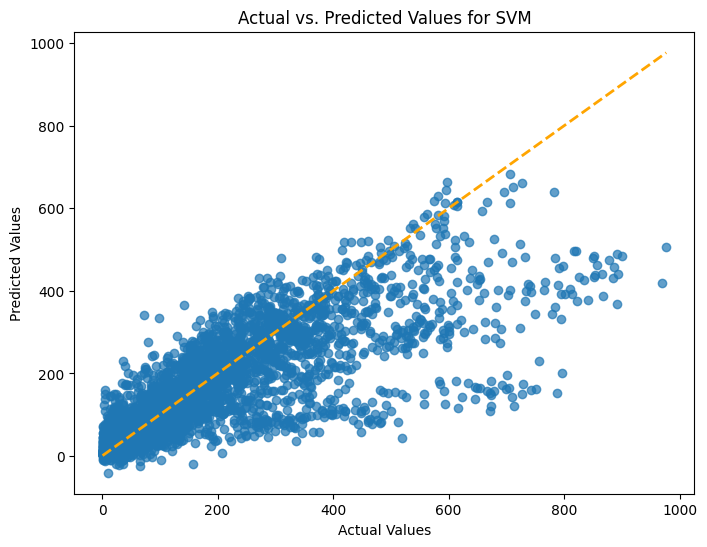

In [26]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error

url_bike = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df_bike = pd.read_csv(url_bike)
df_bike.head(10)


df_bike.info()


df_bike = df_bike.drop(['dteday','instant','casual','registered'], axis=1) #Drop the date as it is an uncompatible datatype, drops instant casual and registred as they are part of cnt.
corr_matrix_bike = df_bike.corr() #Creates a correlation matrix
corr_matrix_bike['cnt'].sort_values(ascending=False) #The correlation matrix focuses on the correlation between the remaining columns to count, aka count of total rental bikes including both casual and registered


x_bike = df_bike.drop('cnt', axis=1) # Dropping count as we want this as our predictor
y_bike = df_bike['cnt']


#Split into train and test data sets.
X_train_bike, X_test_bike, y_train_bike, y_test_bike = train_test_split(x_bike,y_bike, test_size=0.2, random_state=42) #WE use a  80/20 split. Common practice in train / test splitted data.
#Training.
bike_reg = LinearRegression()
bike_reg.fit(X_train_bike, y_train_bike)
y_pred_bike = bike_reg.predict(X_test_bike)


#calc mse, mae, etc..
bike_mse = mean_squared_error(y_test_bike, y_pred_bike)
bike_mae = mean_absolute_error(y_test_bike, y_pred_bike)
bike_rmse = root_mean_squared_error(y_test_bike, y_pred_bike)
bike_r2 = r2_score(y_test_bike, y_pred_bike)
#Print results.
print(f"Mean Squared Error: {bike_mse}")
print(f"Mean Absolute Error: {bike_mae}")
print(f"Root Mean Squared Error: {bike_rmse}")
print(f"R2 Score: {bike_r2}")



plt.figure(figsize=(8, 6))
plt.scatter(y_test_bike, y_pred_bike, alpha=0.5)


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test_bike), max(y_test_bike)], [min(y_test_bike), max(y_test_bike)], linestyle='--', color='red', lw=2)

plt.show()

# As we can see these results are not very good. Therefore we will move on to a more advanced model. Like a SVM and a XGBoost.


# Defining and trainging the XGBoost model.
X,y = x_bike, y_bike
dtrain = xgb.DMatrix(X_train_bike, label=y_train_bike)
dtest = xgb.DMatrix(X_test_bike, label=y_test_bike)

vibe = xgb.XGBRegressor()
vibe.fit(X_train_bike, y_train_bike)
y_pred_bike_xgb = vibe.predict(X_test_bike)
vibe.save_model('xgboost_model_bike.model')


#Calculation of evaluation metrics
xgb_bike_mse = mean_squared_error(y_test_bike, y_pred_bike_xgb)
xgb_bike_mae = mean_absolute_error(y_test_bike, y_pred_bike_xgb)
xgb_bike_rmse = root_mean_squared_error(y_test_bike, y_pred_bike_xgb)
xgb_bike_r2 = r2_score(y_test_bike, y_pred_bike_xgb)

#Print the results
print(f"XGBoost Mean Squared Error: {xgb_bike_mse}")
print(f"XGBoost Mean Absolute Error: {xgb_bike_mae}")
print(f"XGBoost Root Mean Squared Error: {xgb_bike_rmse}")
print(f"XGBoost R2 Score: {xgb_bike_r2}")


xgb.plot_importance(vibe) # This will show us the attributes that impact the models score the most.
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(y_test_bike, y_pred_bike_xgb, alpha=0.5)


plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test_bike), max(y_test_bike)], [min(y_test_bike), max(y_test_bike)], linestyle='--', color='red', lw=2)

plt.show()

# Bike Sharing SVM Model

#Importting and training the model

from sklearn.svm import SVR
svm_reg_bike = SVR()
svm_reg_bike.fit(X_train_bike, y_train_bike)


#Scaling as SVM models are sensetive to features scales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled_bike = scaler.fit_transform(X_train_bike)
X_test_scaled_bike = scaler.transform(X_test_bike)


#Training the SVM Model
svr_bike = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_bike.fit(X_train_scaled_bike, y_train_bike)


#predicting the data
y_pred_bike_svm = svr_bike.predict(X_test_scaled_bike)

#calculating our evaluation metrics
bike_svm_mse = mean_squared_error(y_test_bike, y_pred_bike_svm)
bike_svm_mae = mean_absolute_error(y_test_bike, y_pred_bike_svm)
bike_svm_rmse = root_mean_squared_error(y_test_bike, y_pred_bike_svm)
bike_svm_r2 = r2_score(y_test_bike, y_pred_bike_svm)
 # Print results
print(f"SVM Mean Squared Error: {bike_svm_mse}")
print(f"SVM Mean Absolute Error: {bike_svm_mae}")
print(f"SVM Root Mean Squared Error: {bike_svm_rmse}")
print(f"SVM R2 Score: {bike_svm_r2}")


# Plotting the actual vs. predicted values for the SVM model
plt.figure(figsize=(8, 6))
plt.scatter(y_test_bike, y_pred_bike_svm, alpha=0.7)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values for SVM")

plt.plot([min(y_test_bike), max(y_test_bike)], [min(y_test_bike), max(y_test_bike)], linestyle='--', color='orange', lw=2)

plt.show()